In [9]:
# The first step is to load some standard python packages (numpy, pandas, scipy and matplotlib.pyplot).
import matplotlib.pyplot as plt
# %matplotlib ipympl
import pandas as pd
import numpy as np
import scipy.stats as stats
from matplotlib.dates import DateFormatter
from datetime import timedelta



In [10]:
def plot_pdef_year(df, years):
    """
    Plot the rainfall deficit for a specific year from a larger dataframe. Also show the climatology of rainfall deficit
    """
    # CLIMATOLOGY
        # set up a figure with a given width, height size
    f = plt.figure(figsize=(10, 8))
    # add one subplot to the figure
    ax = f.add_subplot(111)
    # group all the years of data into a regular day of year climatology. This puts all values at the same day of the year into groups
    df_clim = df.groupby(df.index.dayofyear)
    # compute the upper bound of the climatology by taking the 97.5 percentile of each group. result is a day-of-year time series
    upper = df_clim.quantile(0.975)
    # same but for the lower bound
    lower = df_clim.quantile(0.025)
    # Also compute upper and lower bounds for the 25 and 75 percentiles
    upper_2 = df_clim.quantile(0.75)
    lower_2 = df_clim.quantile(0.25)
    # and finally, also compute the median climatology
    median = df_clim.median()
    # prepare a date range for the climatology values, equal to the length of climatology
    clim_dates = pd.date_range(start=df['1979'].index.min(), end=df['1979'].index.max(),freq='D')
    # plot the climatology bounds with different shadings
    ax.fill_between(clim_dates, lower[0:len(clim_dates)], upper[0:len(clim_dates)], color='grey', alpha=0.3, label='95% interval')
    ax.fill_between(clim_dates, lower_2[0:len(clim_dates)], upper_2[0:len(clim_dates)], color='grey', alpha=0.5, label='50% interval')
    # also plot the median
    ax.plot(clim_dates, median[0:len(clim_dates)], label='median', color='k')
    
    # INDIVIDUAL YEARS
    for y in years:
        # retrieve the values of the time series, belonging to 'y'
        df_oneyear = df[df.index.year==y]
        # finally, plot the actual year of interest over the climatology shadings
        ax.plot(clim_dates, df_oneyear, label='{:d}'.format(y))
    
    # finalize plot
    ax.set_xlabel('Time')
    ax.set_ylabel('Deficit (mm)')
    ax.grid()
    ax.legend()
    date_form = DateFormatter("%b")
    ax.xaxis.set_major_formatter(date_form)
    return ax

In [11]:
filename = r'precipitation data volta\mswep\Oti_0.15_8.45.csv'

In [12]:
station = pd.read_csv(filename, index_col=['time'], parse_dates=['time']) 
#Look what is in the file:
station.head(15)

,precipitation
time,
1979-01-01,0.00
1979-01-02,0.00
1979-01-03,0.00
1979-01-04,0.00
1979-01-05,0.00
1979-01-06,0.00
1979-01-07,0.00
1979-01-08,0.00
1979-01-09,0.00


In [13]:
# find dates that fulfill our period of interest (from january to december, but you can also select a different period if you want, e.g. from april to september)
dates_mask = (station.index.month >= 1) & (station.index.month <= 12)
# select data within these dates
station_growing_season = station[dates_mask].copy() # copy makes sure the dataframe is an actual copy and not a slice/view
# show some values in a certain year (1976 in this example)
station_growing_season.loc['1979']


,precipitation
time,
1979-01-01,0.0
1979-01-02,0.0
1979-01-03,0.0
1979-01-04,0.0
1979-01-05,0.0
...,...
1979-12-27,0.0
1979-12-28,0.0
1979-12-29,0.0


In [14]:
# add the columns Epot_mm_day and P_mm_day
evaporation = pd.read_excel(
    'evaporation_daily_design_year.xlsx',
    parse_dates=['valid_time'],
    index_col='valid_time'
)
station_growing_season.loc[:,'Epot_mm_day'] = evaporation['evap_mm'] # we don't have potential evaporation data, so we set it to zero. This means that the deficit will be equal to the precipitation, which is not realistic but allows us to show the concept of deficit.
station_growing_season.loc[:,'P_mm_day'] = np.maximum(0,station_growing_season.loc[:,'precipitation']) # values of -1 indicate that rainfall is too low to really measure it properly

In [15]:
# ... add a 'Epot-P' column 
station_growing_season.loc[:,'Epot-P'] = station_growing_season.Epot_mm_day - station_growing_season.P_mm_day
station_growing_season.head(30)

,precipitation,Epot_mm_day,P_mm_day,Epot-P
time,,,,
1979-01-01,0.00,3.855330,0.00,3.855330
1979-01-02,0.00,3.834547,0.00,3.834547
1979-01-03,0.00,3.645378,0.00,3.645378
1979-01-04,0.00,3.272166,0.00,3.272166
1979-01-05,0.00,3.367551,0.00,3.367551
1979-01-06,0.00,2.984087,0.00,2.984087
1979-01-07,0.00,3.743220,0.00,3.743220
1979-01-08,0.00,3.477171,0.00,3.477171
1979-01-09,0.00,3.487550,0.00,3.487550


In [16]:
# Now we compute the cumulative potential rainfall deficit per year. What do we need to keep in mind
# We want to take the cumulative sum, but the values should not become negative
# We want to apply this per season (the cumulative sum should reset to zero each hydrological year)
# To achieve this we use the function below
def compute_non_negative_deficit(series):
    def non_negative_cumsum(s):
        result = []
        total = 0
        for val in s:
            total = max(0, total + val)
            result.append(total)
        return pd.Series(result, index=s.index)

    # Apply the function and flatten the index
    result = series.groupby(series.index.year).apply(non_negative_cumsum) # Assures applying the function per year!
    result.index = result.index.droplevel(0)  # Remove the year level, keep DatetimeIndex
    return result

rainfall_deficit_by_year = compute_non_negative_deficit(station_growing_season['Epot-P'])

In [17]:
rainfall_deficit_by_year.loc['1979']

time
1979-01-01       3.855330
1979-01-02       7.689877
1979-01-03      11.335255
1979-01-04      14.607421
1979-01-05      17.974972
                 ...     
1979-12-27    3081.523950
1979-12-28    3087.627350
1979-12-29    3093.292452
1979-12-30    3099.194290
1979-12-31    3105.276451
Name: Epot-P, Length: 365, dtype: float64

In [18]:
# ... what is the value of the cumulative potential rainfall_deficit on 15 September 1976? 
# ... DO NOT FORGET TO INCLUDE UNITS (typical exam question)

# option 1
print(rainfall_deficit_by_year.loc['1979'].tail(20))
# then read from the table and provide your answer

# option 2
print(rainfall_deficit_by_year.loc['1979-09-15'])

print('the answer is ' + f"{rainfall_deficit_by_year.loc['1979-09-15']:.0f}" + ' mm')

time
1979-12-12    2977.862249
1979-12-13    2986.023974
1979-12-14    2993.908405
1979-12-15    3001.780587
1979-12-16    3009.337470
1979-12-17    3016.515180
1979-12-18    3023.673642
1979-12-19    3030.948227
1979-12-20    3037.446147
1979-12-21    3040.636440
1979-12-22    3045.643660
1979-12-23    3053.255130
1979-12-24    3061.026664
1979-12-25    3068.257804
1979-12-26    3075.221337
1979-12-27    3081.523950
1979-12-28    3087.627350
1979-12-29    3093.292452
1979-12-30    3099.194290
1979-12-31    3105.276451
Name: Epot-P, dtype: float64
1714.580666862821
the answer is 1715 mm


In [19]:
def plot_pdef_year(df, years):
    clim_dates = pd.date_range('2000-01-01', periods=365)  # climatology 365 dagen
    
    fig, ax = plt.subplots(figsize=(10,5))
    
    for y in years:
        df_oneyear = df[df.index.year == y]
        
        # verwijder 29 februari als het schrikkeljaar is
        if len(df_oneyear) == 366:
            df_oneyear = df_oneyear[df_oneyear.index.dayofyear != 60]
        
        ax.plot(clim_dates, df_oneyear.values, label=str(y))
    
    ax.set_xlabel('Dag van het jaar')
    ax.set_ylabel('Rainfall deficit (mm)')
    ax.legend()
    return ax

In [20]:
def fit(ts, dist='gamma'):
    """
    This function fits a gamma distribution from a number of samples. It can be tested
    whether the process fits a Gamma distribution, because the function exports besides
    the fit parameters alpha and beta both the empirical plotting positions
    (x/(n+1)) and the plotting positions based on the fitted Gamma distribution.
    These can be used to construct goodness of fit or Q-Q plots
    Input:
        samples            : the samples from the process, to be described by
                             the Gamma distribution
    Output:
        alpha              : the shape parameter of the distribution
        loc                : the location (mean) parameter of the distribution
        beta               : the scale parameter of the distribution
        prob_zero          : the probability of zero-rainfall
        plot_pos_emp       : empirical plotting positions
        plot_pos_par       : parameterized plotting positions

    """

    samples = ts.values.flatten()  # flatten the matrix to a one-dimensional array
    # compute probability of zero rainfall
    prob_zero = float(sum(samples == 0)) / len(samples)
    # find the amount of samples
    n = len(samples)
    if dist == 'gamma':
        # select the gamma distribution function to work with
        dist_func = stats.gamma
    elif dist == 'gev':
        # select the generalized extreme value distribution function to work with
        dist_func = stats.genextreme
    # fit parameters of chosen distribution function, only through non-zero samples
    fit_params = dist_func.fit(samples[(samples != 0) & np.isfinite(samples)])
    # following is returned from the function
    return fit_params, prob_zero

def quantile_trans(ts, fit_params, p_zero, dist='gamma'):
    """
    This function detrermines the normal quantile transform of a number of samples, based on
    a known Gamma distribution of the precipitation process (can in principle
    be extended to support grids instead of point values)
    Input:
        samples            : the samples from the process, for which SPI is
                             computed
        alpha              : the shape parameter of the distribution
        loc                : the location (mean) parameter of the distribution
        beta               : the scale parameter of the distribution
        prob_zero          : the probability of zero-rainfall
    Output:
        SPI                : SPI values of the given samples
    """
    # compute probability of underspending of given sample(s), given the predefined Gamma distribution
    samples = ts.values
    # find zero samples
    ii = samples == 0
    # find missings in samples
    jj = np.isnan(samples)
    if dist == 'gamma':
        # select the gamma distribution function to work with
        dist_func = stats.gamma
    elif dist == 'gev':
        # select the gev distribution function to work with
        dist_func = stats.genextreme
    # compute the cumulative distribution function quantile values using the fitted parameters
    cdf_samples = dist_func.cdf(samples, *fit_params)
    # correct for no rainfall probability
    cdf_samples = p_zero + (1 - p_zero) * cdf_samples
    cdf_samples[ii] = p_zero
    cdf_samples[jj] = np.nan
    # compute inverse normal distribution with mu=0 and sigma=1, this yields the SPI value. 
    # Basically this means looking up how many standard deviations the given quantile represents in 
    # a normal distribution with mu=0. and sigma=1.
    SPI = stats.norm.ppf(cdf_samples)
    return SPI

def fit_and_transform(samples, dist='gamma'):
    # The function below fits the samples to the requested distribution 'gamma' or 'gev'
    fit_params, p_zero = fit(samples, dist=dist)
    # Then the fitted parameters are used to estimate the SPI for each invidual month
    spi_samples = quantile_trans(samples, fit_params, p_zero, dist=dist)
    # finally, the spi samples are put into a pandas timeseries again, so that we can easily make time series plots
    # and do further analyses
    return pd.Series(spi_samples, index=samples.index)

def compute_standard_index(ts, index='time.month', dist='gamma'):
    """
    Compute standardised index (e.g. SPI, SPEI). This is done on monthly time series by:
    - grouping the monthly data into monthly bins
    - for each month fit a distribution function (gamma or gev)
    - estimate the probability of exceedance of each point in the time series using the 12 distributions
    - estimate the normal transform of each probability found using mapping to a standard normal distribution
    Input:
        ts: pandas Series object containing monthly data (e.g. monthly precipitation, precip-ref. evaporation)
        index='time.month': index to use for grouping
        dist='gamma': distribution to use. Currently implemented are 'gamma' (default) and 'gev'.
    """
    # first, we group all values per month. So we get a group of January rainfalls, February rainfalls, etc.
    ts_group = ts.groupby(index)
    # for each group, the SPI values are computed and coerced into a new time series. 
    spi = ts_group.apply(fit_and_transform, dist=dist)
    spi = spi.sort_index(level=1)
    return spi

In [21]:
# select precipitation only, we don't need anything else.
P = np.maximum(station['precipitation'], 0.) # converted to mm/day
# take monthly sums (a.k.a. monthlies)
P_month = P.resample('M').sum()  
# rename the data
P_month = P_month.rename('P_month')
# add to a larger dataframe
MonthFrame = pd.DataFrame(P_month)
MonthFrame.head()

C:\Users\ellis\AppData\Local\Temp\ipykernel_5532\502890636.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  P_month = P.resample('M').sum()


,P_month
time,
1979-01-31,2.11
1979-02-28,0.12
1979-03-31,67.49
1979-04-30,108.33
1979-05-31,138.56


In [22]:
# compute the spi using our nice function.
spi = compute_standard_index(P_month, index=P_month.index.month)
# add to our larger dataframe and rename
MonthFrame['SPI-01'] = spi.values
# observe the result in a table for the last five years
MonthFrame[-60:]

,P_month,SPI-01
time,,
2012-11-30,17.57,3.959226
2012-12-31,0.00,-0.479506
2013-01-31,0.10,-0.174345
2013-02-28,29.87,1.671257
2013-03-31,74.53,0.789089
2013-04-30,123.67,0.578786
2013-05-31,162.31,0.898443
2013-06-30,104.49,-1.372260
2013-07-31,97.64,-2.170213


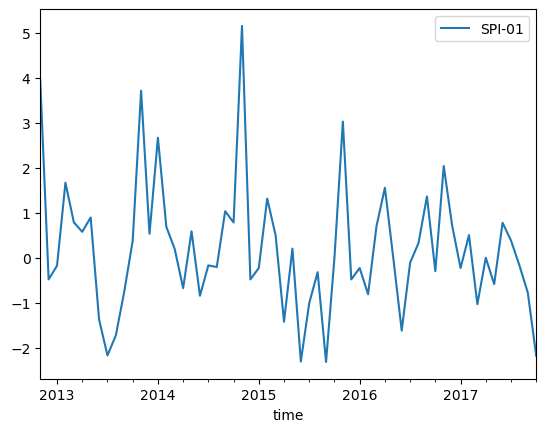

In [23]:
# plot the last 5 year values of spi
plt.figure()
MonthFrame['SPI-01'][-60:].plot()
# add a legend
plt.legend()
plt.show()

In [24]:
# compute 3-monthly SPI with the same function. We only need to first accumulate our data to 3-monthly values.
P_3month_rolling = P_month.rolling(3).sum()
print(P_3month_rolling)

time
1979-01-31       NaN
1979-02-28       NaN
1979-03-31     69.72
1979-04-30    175.94
1979-05-31    314.38
               ...  
2017-06-30    387.67
2017-07-31    474.17
2017-08-31    546.65
2017-09-30    544.60
2017-10-31    382.56
Freq: ME, Name: P_month, Length: 466, dtype: float64


In [25]:
# ... calculate the spi_03
spi_3 = compute_standard_index(P_3month_rolling, index=P_3month_rolling.index.month)
# ... add this again to our larger dataframe and observe the output for the last five years
MonthFrame['SPI-03'] = spi_3.values
MonthFrame[-60:]

,P_month,SPI-01,SPI-03
time,,,
2012-11-30,17.57,3.959226,0.350434
2012-12-31,0.00,-0.479506,0.890016
2013-01-31,0.10,-0.174345,-0.051751
2013-02-28,29.87,1.671257,0.517629
2013-03-31,74.53,0.789089,1.047850
2013-04-30,123.67,0.578786,1.166020
2013-05-31,162.31,0.898443,1.140226
2013-06-30,104.49,-1.372260,0.184712
2013-07-31,97.64,-2.170213,-1.435672


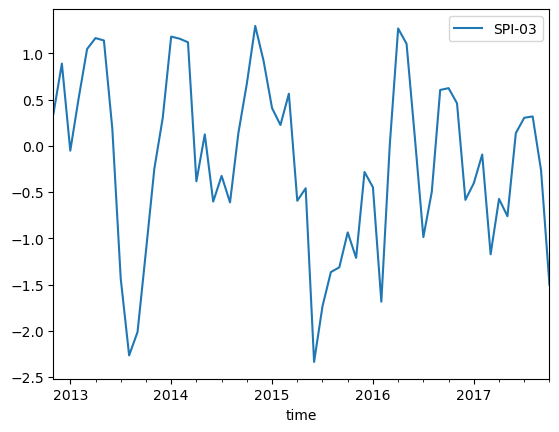

In [26]:
# ... again plot the last 5 years and add a legend
plt.figure()
MonthFrame['SPI-03'][-60:].plot()
# add a legend
plt.legend()
plt.show()

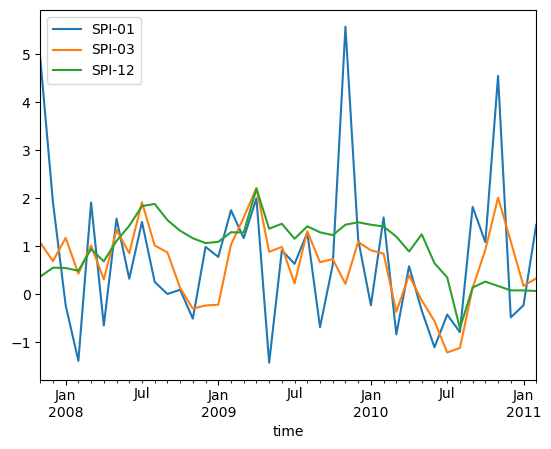

In [27]:
# ... compute 12 monthly SPI and do the plotting
P_12month_rolling = P_month.rolling(12).sum()
spi_12 = compute_standard_index(P_12month_rolling, index=P_month.index.month)
MonthFrame['P_12m'] = P_12month_rolling
MonthFrame['SPI-12'] = spi_12.values
MonthFrame[-60:]
# ... again plot the last 5 years and add a legend
MonthFrame[['SPI-01','SPI-03','SPI-12']][-120:-80].plot()
plt.legend()
plt.show()

In [28]:
def spells(df, wet_threshold = 1):
        '''This function calculates the dry spells for a growing season. A dry spell is indexed on its last day.
        Note: This function does not support a growing season spanning different calendar years.
        
        :: Inputs ::
        df = dataframe containing just growing season information, assuming daily data
        wet_threshold: Minimum precipitation for what constitutes a wet day in mm/day.
        
        :: Outputs :: 
        ds: DataFrame with dry spells
        '''
        
        df['DRY'] = (df['P_mm_day'] < wet_threshold) # Adding a column checking for dry and wet days. dry == True, wet == False
        Years = np.unique(df.index.year)
        spells_stored = []
        spell_end_dates = []
        for j in np.arange(len(Years)):
            df_year = df.loc[str(Years[j])]
            spell_length_counter = 0
            i = 0 # day counter
            while i < len(df_year):
                dry_day = df_year['DRY'].iloc[i]
                if dry_day == True: # increase the counter
                    spell_length_counter += 1
                else: # dry_day == False; Report a dry spell the moment that a wet day arrives:
                    if spell_length_counter != 0:
                        spells_stored += [spell_length_counter] # store previous spell in new list
                        spell_end_dates += [df_year.index[i-1]] # store associated end date in new list
                        spell_length_counter = 0 # reset spell_length_counter
                i += 1
 
        ds = pd.DataFrame(data = spells_stored, index = spell_end_dates)
        ds.columns = ['Dry Spell Length']
        return ds

In [29]:
# remember that we have already have a dataframe (from exercise 2.1) with the daily values of several variables including daily precipitation
station_growing_season.head(10)

,precipitation,Epot_mm_day,P_mm_day,Epot-P
time,,,,
1979-01-01,0.0,3.855330,0.0,3.855330
1979-01-02,0.0,3.834547,0.0,3.834547
1979-01-03,0.0,3.645378,0.0,3.645378
1979-01-04,0.0,3.272166,0.0,3.272166
1979-01-05,0.0,3.367551,0.0,3.367551
1979-01-06,0.0,2.984087,0.0,2.984087
1979-01-07,0.0,3.743220,0.0,3.743220
1979-01-08,0.0,3.477171,0.0,3.477171
1979-01-09,0.0,3.487550,0.0,3.487550


In [30]:
# gebruik de juiste kolom in mm/dag en correcte index
SimpleStation = station_growing_season[['P_mm_day']]

# bereken droge periodes
DrySpells = spells(SimpleStation, wet_threshold=1)

# have look at the data in general
DrySpells.tail(20)



C:\Users\ellis\AppData\Local\Temp\ipykernel_5532\3018613529.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['DRY'] = (df['P_mm_day'] < wet_threshold) # Adding a column checking for dry and wet days. dry == True, wet == False


,Dry Spell Length
2017-07-05,1
2017-07-12,5
2017-07-18,1
2017-07-29,1
2017-08-03,1
2017-08-11,3
2017-08-16,2
2017-08-21,3
2017-08-28,2
2017-08-31,1


In [31]:
# and have a look at the maximum dry spells
DrySpells.sort_values(by='Dry Spell Length',ascending=False).head(20)

,Dry Spell Length
2008-03-09,69
1989-03-09,68
1995-03-08,67
2002-03-07,66
1984-03-06,66
2001-03-04,63
1997-03-17,62
1992-03-01,61
1979-03-13,60
2016-02-28,59


Dry Spell Length
1     1011
2      533
3      206
4      112
5       64
6       43
7       21
8       21
9       15
10      10
11       6
12       9
13       9
14       4
15       3
16       3
17       6
18       3
19       5
20       3
21       3
22       1
23       4
24       1
25       1
26       4
27       2
28       4
29       3
31       3
32       1
34       1
35       4
36       2
38       2
39       1
41       2
42       1
43       2
44       4
46       1
47       1
48       2
56       2
57       1
59       1
60       1
61       1
62       1
63       1
66       2
67       1
68       1
69       1
Name: count, dtype: int64
d = [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 31 32 34 35 36 38 39 41 42 43 44 46 47 48 56 57 59 60 61
 62 63 66 67 68 69]
n_occ = [1011  533  206  112   64   43   21   21   15   10    6    9    9    4
    3    3    6    3    5    3    3    1    4    1    1    4    2    4
    3    3    1    1    4    2    2    1   

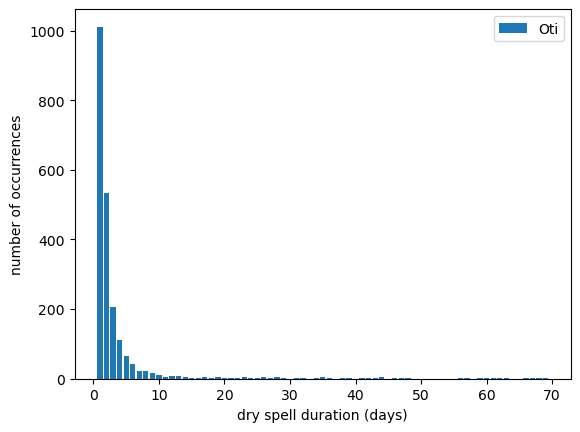

In [32]:
# compute the variables above
values = DrySpells['Dry Spell Length'].value_counts().sort_index()
print(values)

d = np.array(values.index)
print('d = ' + str(d))

n_occ = np.array(values)
print('n_occ = ' + str(n_occ))

plt.bar(d,n_occ, label = 'Oti')
plt.xlabel('dry spell duration (days)')
plt.ylabel('number of occurrences')
plt.legend()
plt.show()

In [33]:
# ... continue computing the other variables

# spells>=d, n_ex i.e. the total number of equal to or exceedance
n_ex = np.zeros(len(d))
for i in range(len(n_ex)):
    n_ex[i] = np.sum(n_occ[i:])
print(n_ex)

# rate of exceedance, r (1/year)
y = len(np.unique(station_growing_season.index.year))
r = n_ex/y
print(r)

p = 1-np.exp(-r*1)
print(p)

[2.150e+03 1.139e+03 6.060e+02 4.000e+02 2.880e+02 2.240e+02 1.810e+02
 1.600e+02 1.390e+02 1.240e+02 1.140e+02 1.080e+02 9.900e+01 9.000e+01
 8.600e+01 8.300e+01 8.000e+01 7.400e+01 7.100e+01 6.600e+01 6.300e+01
 6.000e+01 5.900e+01 5.500e+01 5.400e+01 5.300e+01 4.900e+01 4.700e+01
 4.300e+01 4.000e+01 3.700e+01 3.600e+01 3.500e+01 3.100e+01 2.900e+01
 2.700e+01 2.600e+01 2.400e+01 2.300e+01 2.100e+01 1.700e+01 1.600e+01
 1.500e+01 1.300e+01 1.100e+01 1.000e+01 9.000e+00 8.000e+00 7.000e+00
 6.000e+00 5.000e+00 3.000e+00 2.000e+00 1.000e+00]
[5.51282051e+01 2.92051282e+01 1.55384615e+01 1.02564103e+01
 7.38461538e+00 5.74358974e+00 4.64102564e+00 4.10256410e+00
 3.56410256e+00 3.17948718e+00 2.92307692e+00 2.76923077e+00
 2.53846154e+00 2.30769231e+00 2.20512821e+00 2.12820513e+00
 2.05128205e+00 1.89743590e+00 1.82051282e+00 1.69230769e+00
 1.61538462e+00 1.53846154e+00 1.51282051e+00 1.41025641e+00
 1.38461538e+00 1.35897436e+00 1.25641026e+00 1.20512821e+00
 1.10256410e+00 1.025641

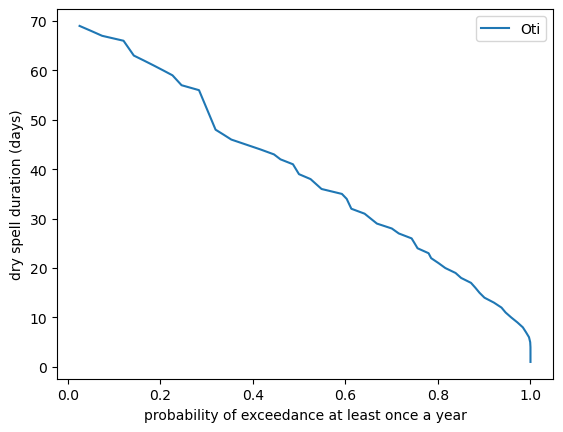

In [34]:
# ... plot the graph
plt.figure()
plt.plot(p,d, label = 'Oti')
plt.xlabel('probability of exceedance at least once a year')
plt.ylabel('dry spell duration (days)')
plt.legend()
plt.show()

In [35]:
# Optionally run this code after computing all variables to put them in a nice table 
data = {'d': d, 'n_occ': n_occ, 'n_ex': np.int64(n_ex), 'r': r, 'p': p}
DryTable = pd.DataFrame.from_dict(data)
DryTable.head(61)

,d,n_occ,n_ex,r,p
0,1,1011,2150,55.128205,1.000000
1,2,533,1139,29.205128,1.000000
2,3,206,606,15.538462,1.000000
3,4,112,400,10.256410,0.999965
4,5,64,288,7.384615,0.999379
5,6,43,224,5.743590,0.996797
6,7,21,181,4.641026,0.990352
7,8,21,160,4.102564,0.983470
8,9,15,139,3.564103,0.971678
9,10,10,124,3.179487,0.958393


In [36]:
print(len(station_growing_season))

14184


Return periods T (years):
[1.81395349e-02 3.42405619e-02 6.43564356e-02 9.75000000e-02
 1.35416667e-01 1.74107143e-01 2.15469613e-01 2.43750000e-01
 2.80575540e-01 3.14516129e-01 3.42105263e-01 3.61111111e-01
 3.93939394e-01 4.33333333e-01 4.53488372e-01 4.69879518e-01
 4.87500000e-01 5.27027027e-01 5.49295775e-01 5.90909091e-01
 6.19047619e-01 6.50000000e-01 6.61016949e-01 7.09090909e-01
 7.22222222e-01 7.35849057e-01 7.95918367e-01 8.29787234e-01
 9.06976744e-01 9.75000000e-01 1.05405405e+00 1.08333333e+00
 1.11428571e+00 1.25806452e+00 1.34482759e+00 1.44444444e+00
 1.50000000e+00 1.62500000e+00 1.69565217e+00 1.85714286e+00
 2.29411765e+00 2.43750000e+00 2.60000000e+00 3.00000000e+00
 3.54545455e+00 3.90000000e+00 4.33333333e+00 4.87500000e+00
 5.57142857e+00 6.50000000e+00 7.80000000e+00 1.30000000e+01
 1.95000000e+01 3.90000000e+01]


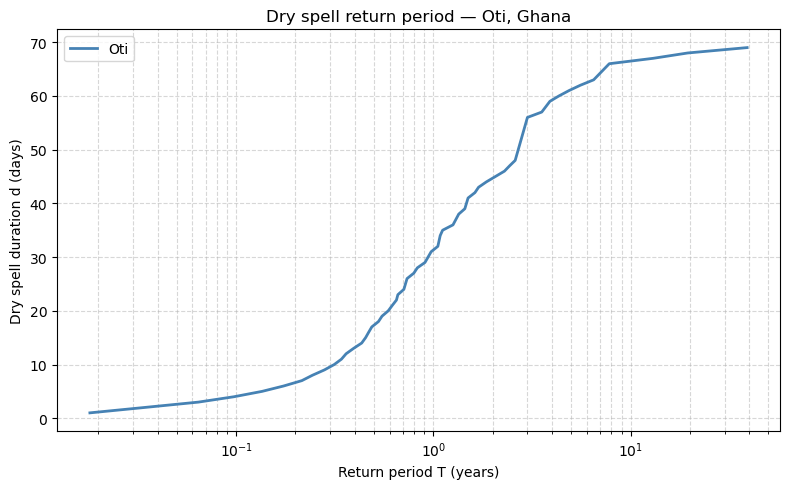

           d (days)
T (years)          
0.5              17
1.0              31
2.0              44
5.0              61
10.0             66
20.0             68
50.0             69


,d (days)
T (years),
0.5,17
1.0,31
2.0,44
5.0,61
10.0,66
20.0,68
50.0,69


In [37]:
# ============================================================
# RETURN PERIODS FOR DRY SPELLS — Black Volta, Ghana
# ============================================================
# This code builds on the existing DryTable (d, n_occ, n_ex, r, p)
# Make sure DryTable is already computed before running this.

# --- 1. Calculate return period T (years) ---
# T = 1/r: the average number of years between occurrences of a dry spell >= d days
T = 1 / r
print('Return periods T (years):')
print(T)

# Add to DryTable
DryTable['T'] = T
DryTable


# --- 2. Plot: Return period vs dry spell duration ---
plt.figure(figsize=(8, 5))
plt.plot(T, d, color='steelblue', linewidth=2, label='Oti')
plt.xscale('log')  # log scale, just like in the rainfall analysis
plt.xlabel('Return period T (years)')
plt.ylabel('Dry spell duration d (days)')
plt.title('Dry spell return period — Oti, Ghana')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


# --- 3. Look up dry spell duration for specific return periods ---
# Same approach as in the rainfall DDF analysis
return_periods = np.array([0.5, 1, 2, 5, 10, 20, 50])

# For each return period, find the closest d value
d_at_T = np.empty(return_periods.shape)
for i in np.arange(len(return_periods)):
    target_T = return_periods[i]
    # find index of T closest to target_T
    idx = (np.abs(T - target_T)).argmin()
    d_at_T[i] = d[idx]

# Store in a summary DataFrame
ReturnLevelTable = pd.DataFrame({
    'T (years)': return_periods,
    'd (days)': d_at_T.astype(int)
})
ReturnLevelTable = ReturnLevelTable.set_index('T (years)')
print(ReturnLevelTable)
ReturnLevelTable


RETURN PERIOD OF A DRY SPELL >= 10 DAYS
  Dataset length:                  38.8 years
  Total spells >= 10 days:         124
  Rate of exceedance (r):          3.193 per year
  Return period (T = 1/r):         0.31 years
  Annual exceedance probability:   95.9%
  A dry spell >= 10 days occurs on average
  once every 0.3 years (96% chance per year).
Total dry spell events >= 10 days: 127

Dry spell events >= 10 days with SPI-3 context:
start_date   end_date  length_days     SPI-3     SPI3_context
2001-10-19 2002-03-07          140  0.136096     normal / wet
2000-10-29 2001-03-04          127 -1.388436 moderate drought
1994-11-05 1995-03-08          124 -0.893390       mildly dry
2015-11-02 2016-02-28          119 -1.685652   severe drought
2012-11-09 2013-02-25          109  0.517629     normal / wet
2002-11-06 2003-02-13          100  0.749801     normal / wet
1986-11-08 1987-02-13           98  0.169052     normal / wet
2006-11-03 2007-02-07           97 -0.573673       mildly dry
200

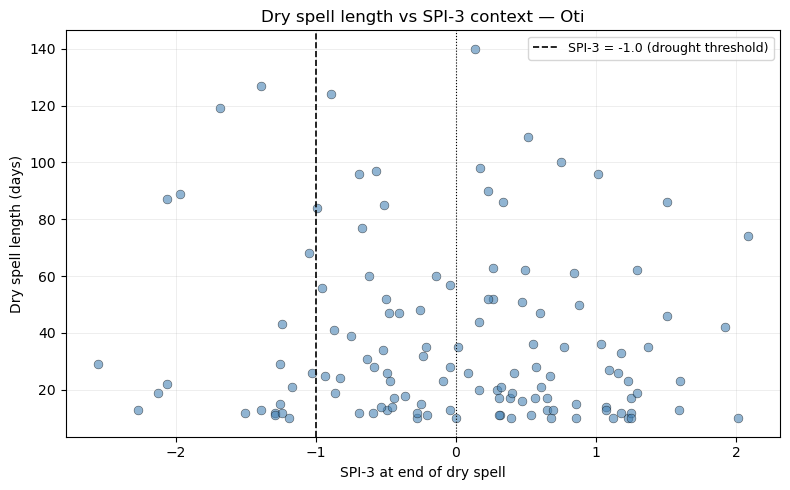

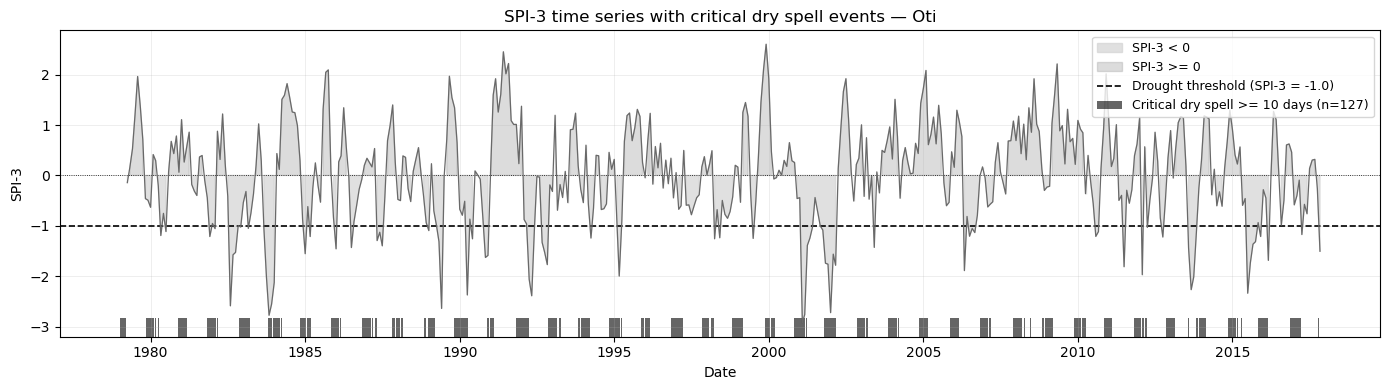


--- Top 15 longest dry spell events ---
start_date   end_date  length_days  SPI-3     SPI3_context
2001-10-19 2002-03-07          140   0.14     normal / wet
2000-10-29 2001-03-04          127  -1.39 moderate drought
1994-11-05 1995-03-08          124  -0.89       mildly dry
2015-11-02 2016-02-28          119  -1.69   severe drought
2012-11-09 2013-02-25          109   0.52     normal / wet
2002-11-06 2003-02-13          100   0.75     normal / wet
1986-11-08 1987-02-13           98   0.17     normal / wet
2006-11-03 2007-02-07           97  -0.57       mildly dry
2007-12-05 2008-03-09           96   1.02     normal / wet
1992-11-10 1993-02-13           96  -0.69       mildly dry
2014-11-13 2015-02-10           90   0.23     normal / wet
2011-10-24 2012-01-20           89  -1.97   severe drought
1991-12-06 1992-03-01           87  -2.06  extreme drought
2010-11-19 2011-02-12           86   0.33     normal / wet
1983-12-12 1984-03-06           86   1.51     normal / wet
5‑year return l

In [38]:
# ============================================================
# DRY SPELL EVENTS (>= 10 days) LINKED TO SPI-3 CONDITIONS
# ============================================================
# This code builds on existing variables in your notebook:
#   - station      : daily precipitation DataFrame
#   - MonthFrame   : monthly DataFrame with SPI-01, SPI-03, SPI-12
# ============================================================

WET_THRESHOLD = 1   # mm/day — consistent with earlier analysis
MIN_SPELL     = 10  # days — critical threshold for crops

# ============================================================
# Step 0: Return period of a dry spell >= 10 days
# ============================================================
# Uses DryTable from your notebook (columns: d, n_occ, n_ex, r, p)

N_years = len(station) / 365.25

# Look up n_ex at d = MIN_SPELL (number of spells >= 10 days)
row = DryTable[DryTable['d'] == MIN_SPELL]
if len(row) == 0:
    # if exact value not in table, take closest
    idx  = (DryTable['d'] - MIN_SPELL).abs().idxmin()
    row  = DryTable.loc[[idx]]

n_ex_10 = row['n_ex'].values[0]
d_used  = row['d'].values[0]

r_10 = n_ex_10 / N_years   # mean annual exceedance rate
T_10 = 1 / r_10            # return period
p_10 = 1 - np.exp(-r_10)   # annual exceedance probability

print("=" * 55)
print(f"RETURN PERIOD OF A DRY SPELL >= {MIN_SPELL} DAYS")
print("=" * 55)
print(f"  Dataset length:                  {N_years:.1f} years")
print(f"  Total spells >= {d_used} days:         {int(n_ex_10)}")
print(f"  Rate of exceedance (r):          {r_10:.3f} per year")
print(f"  Return period (T = 1/r):         {T_10:.2f} years")
print(f"  Annual exceedance probability:   {p_10*100:.1f}%")
print("=" * 55)
print(f"  A dry spell >= {MIN_SPELL} days occurs on average")
print(f"  once every {T_10:.1f} years ({p_10*100:.0f}% chance per year).")
print("=" * 55)
# ============================================================
# Step 1: Identify all dry spell events >= 10 days
# ============================================================
def find_dry_spell_events(daily_series, wet_threshold=1, min_length=10):
    """
    Find all dry spell events >= min_length consecutive dry days.
    Returns a DataFrame with start date, end date and length.
    """
    P     = np.maximum(daily_series, 0)
    dry   = P < wet_threshold
    events, spell_start, spell_length = [], None, 0

    for date, is_dry in dry.items():
        if is_dry:
            if spell_length == 0:
                spell_start = date
            spell_length += 1
        else:
            if spell_length >= min_length:
                events.append({
                    'start_date':  spell_start,
                    'end_date':    date - pd.Timedelta(days=1),
                    'length_days': spell_length
                })
            spell_length = 0
            spell_start  = None

    # catch spell running to end of record
    if spell_length >= min_length:
        events.append({
            'start_date':  spell_start,
            'end_date':    dry.index[-1],
            'length_days': spell_length
        })

    return pd.DataFrame(events)


CriticalSpells = find_dry_spell_events(
    station['precipitation'],
    wet_threshold=WET_THRESHOLD,
    min_length=MIN_SPELL
)
print(f"Total dry spell events >= {MIN_SPELL} days: {len(CriticalSpells)}")
CriticalSpells.head(10)


# ============================================================
# Step 2: Look up SPI-3 for each event (month of end date)
# ============================================================
def get_spi_for_month(date, spi_series):
    """Return the SPI value for the month containing 'date'."""
    mask = (spi_series.index.year  == date.year) & \
           (spi_series.index.month == date.month)
    matches = spi_series[mask]
    return matches.iloc[0] if len(matches) > 0 else np.nan

CriticalSpells['SPI-3'] = CriticalSpells['end_date'].apply(
    lambda d: get_spi_for_month(d, MonthFrame['SPI-03'])
)

# Classify SPI-3 context
def spi_label(spi):
    if   pd.isna(spi):   return 'unknown'
    elif spi <= -2.0:    return 'extreme drought'
    elif spi <= -1.5:    return 'severe drought'
    elif spi <= -1.0:    return 'moderate drought'
    elif spi <  0:       return 'mildly dry'
    else:                return 'normal / wet'

CriticalSpells['SPI3_context'] = CriticalSpells['SPI-3'].apply(spi_label)

print("\nDry spell events >= 10 days with SPI-3 context:")
print(CriticalSpells.sort_values('length_days', ascending=False)
                    .head(20).to_string(index=False))


# ============================================================
# Step 3: Summary statistics per SPI-3 class
# ============================================================
context_summary = CriticalSpells.groupby('SPI3_context').agg(
    count       =('length_days', 'count'),
    mean_length =('length_days', 'mean'),
    max_length  =('length_days', 'max')
).round(1)

print("\n--- Distribution of critical dry spells by SPI-3 context ---")
print(context_summary)

n_total    = len(CriticalSpells)
n_drought  = (CriticalSpells['SPI-3'] <= -1.0).sum()
n_moderate = ((CriticalSpells['SPI-3'] <= -1.0) & (CriticalSpells['SPI-3'] > -1.5)).sum()
n_severe   = ((CriticalSpells['SPI-3'] <= -1.5) & (CriticalSpells['SPI-3'] > -2.0)).sum()
n_extreme  = (CriticalSpells['SPI-3'] <= -2.0).sum()

print(f"\n--- Drought conditions during critical dry spells (SPI-3) ---")
print(f"Total critical dry spell events:                   {n_total}")
print(f"Events under drought conditions (SPI-3 <= -1.0):  {n_drought} ({100 * n_drought  / n_total:.1f}%)")
print(f"  of which moderate drought  (-1.0 to -1.5):      {n_moderate} ({100 * n_moderate / n_total:.1f}%)")
print(f"  of which severe drought    (-1.5 to -2.0):      {n_severe}   ({100 * n_severe   / n_total:.1f}%)")
print(f"  of which extreme drought   (<= -2.0):           {n_extreme}  ({100 * n_extreme  / n_total:.1f}%)")


# ============================================================
# Step 4: Plot 1 — scatter: dry spell length vs SPI-3
# ============================================================
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(
    CriticalSpells['SPI-3'],
    CriticalSpells['length_days'],
    color='steelblue', edgecolors='k', linewidths=0.4,
    alpha=0.6, s=40
)
ax.axvline(x=-1.0, color='k', linestyle='--', linewidth=1.2,
           label='SPI-3 = -1.0 (drought threshold)')
ax.axvline(x=0,    color='k', linestyle=':',  linewidth=0.8)

ax.set_xlabel('SPI-3 at end of dry spell')
ax.set_ylabel('Dry spell length (days)')
ax.set_title('Dry spell length vs SPI-3 context — Oti')
ax.legend(fontsize=9)
ax.grid(alpha=0.3, linewidth=0.5)
plt.tight_layout()
plt.show()


# ============================================================
# Step 5: Plot 2 — SPI-3 time series with dry spell events marked
# ============================================================
fig, ax = plt.subplots(figsize=(14, 4))

# SPI-3 line
ax.plot(MonthFrame.index, MonthFrame['SPI-03'],
        color='dimgrey', linewidth=0.9, zorder=3)

# shade below 0 (dry) and above 0 (wet)
ax.fill_between(MonthFrame.index, MonthFrame['SPI-03'], 0,
                where=MonthFrame['SPI-03'] < 0,
                color='lightgrey', alpha=0.7, label='SPI-3 < 0')
ax.fill_between(MonthFrame.index, MonthFrame['SPI-03'], 0,
                where=MonthFrame['SPI-03'] >= 0,
                color='darkgrey', alpha=0.4, label='SPI-3 >= 0')

# drought threshold line
ax.axhline(y=-1.0, color='k', linestyle='--', linewidth=1.2,
           label='Drought threshold (SPI-3 = -1.0)')
ax.axhline(y=0,    color='k', linestyle=':',  linewidth=0.6)

# mark critical dry spell events as vertical bars at the bottom
for _, row in CriticalSpells.iterrows():
    ax.axvspan(row['start_date'], row['end_date'],
               ymin=0, ymax=0.06,
               color='k', alpha=0.6, linewidth=0)

# single legend entry for dry spells
from matplotlib.patches import Patch
handles, labels = ax.get_legend_handles_labels()
handles.append(Patch(facecolor='k', alpha=0.6,
                     label=f'Critical dry spell >= {MIN_SPELL} days (n={len(CriticalSpells)})'))
ax.legend(handles=handles, fontsize=9, loc='upper right')

ax.set_xlabel('Date')
ax.set_ylabel('SPI-3')
ax.set_title('SPI-3 time series with critical dry spell events — Oti')
ax.grid(alpha=0.3, linewidth=0.5)
plt.tight_layout()
plt.show()


# ============================================================
# Step 6: Top 15 most severe events
# ============================================================
print("\n--- Top 15 longest dry spell events ---")
top15 = (CriticalSpells
         .sort_values('length_days', ascending=False)
         .head(15)
         [['start_date', 'end_date', 'length_days', 'SPI-3', 'SPI3_context']]
         .copy())
top15['SPI-3'] = top15['SPI-3'].round(2)
print(top15.to_string(index=False))


# look up the year(s) of the 5‑year event
d5 = d_at_T[return_periods == 5.][0]                    # duration matching T≈5 yr

# Find critical spells matching this duration
matching_spells = CriticalSpells.loc[CriticalSpells['length_days'] == d5]

if len(matching_spells) > 0:
    yrs5 = matching_spells['end_date'].dt.year.unique()
    print(f"5‑year return level ⇒ dry spell ≃{d5:.0f} days "
          f"occurred in year(s): {sorted(yrs5)}")
else:
    # If exact match not found, find closest instead
    closest_idx = (CriticalSpells['length_days'] - d5).abs().idxmin()
    closest_spell = CriticalSpells.loc[closest_idx]
    actual_length = closest_spell['length_days']
    yrs5 = np.array([closest_spell['end_date'].year])
    print(f"5‑year return level ⇒ dry spell ≃{d5:.0f} days")
    print(f"Closest match: {actual_length:.0f} days in year(s): {sorted(yrs5)}")
    print(f"Event: {closest_spell['start_date'].date()} to {closest_spell['end_date'].date()}")


C:\Users\ellis\AppData\Local\Temp\ipykernel_5532\3966309553.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = rainfall_sep2009_sep2010.resample('M').sum()


,precipitation
time,
2009-09-30,47.78
2009-10-31,147.86
2009-11-30,32.22
2009-12-31,11.32
2010-01-31,0.00
2010-02-28,28.38
2010-03-31,35.08
2010-04-30,123.94
2010-05-31,113.23


Total precipitation in Jan, Feb, Dec 2010: precipitation    39.7
dtype: float64 mm
Total precipitation in Mar–Jun 2010: precipitation    383.64
dtype: float64 mm
Total precipitation in Mar–Jun 2010 with 8.3% reduction: precipitation    351.79788
dtype: float64 mm
Total precipitation in Jul–Sep 2010: precipitation    452.18
dtype: float64 mm
precipitation in Jul–Sep 2010 with 6.8% increase: precipitation    482.92824
dtype: float64 mm
Total precipitation in Sep–Nov 2009: precipitation    227.86
dtype: float64 mm
Total precipitation in Sep–Nov 2009 with 6.6% increase: precipitation    242.89876
dtype: float64 mm


C:\Users\ellis\AppData\Local\Temp\ipykernel_5532\3966309553.py:12: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_jan_feb_dec = jan_feb_dec.resample('M').sum()
C:\Users\ellis\AppData\Local\Temp\ipykernel_5532\3966309553.py:17: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_mar_apr_may_june = mar_apr_may_june.resample('M').sum()
C:\Users\ellis\AppData\Local\Temp\ipykernel_5532\3966309553.py:21: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_new_march_april_may_june = new_march_april_may_june.resample('M').sum()
C:\Users\ellis\AppData\Local\Temp\ipykernel_5532\3966309553.py:26: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_jul_aug_sep = jul_aug_sep.resample('M').sum()
C:\Users\ellis\AppData\Local\Temp\ipykernel_5532\3966309553.py:30: FutureWar

,precipitation
time,
2009-09-16,11.33158
2009-09-17,0.11726
2009-09-18,1.11930
2009-09-19,3.35790
2009-09-20,1.19392
...,...
2010-09-11,26.13396
2010-09-12,9.27024
2010-09-13,1.21752


maximum consecutive dry days in 2010: 61


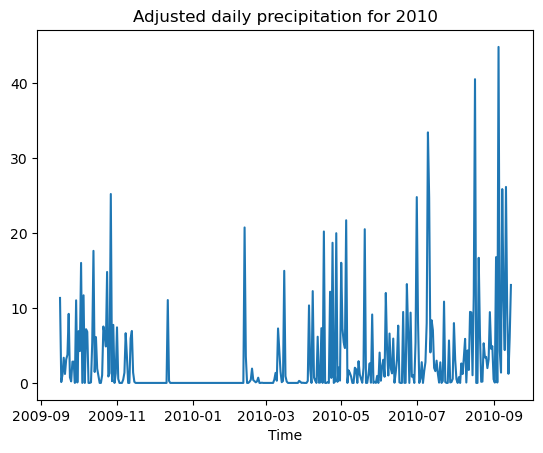

In [39]:
#Dit is een van de toekomstvoorspellingen waar een lange droge periode voorkomt


rainfall_sep2009_sep2010 = station.loc['2009-09-16':'2010-09-15']
monthly = rainfall_sep2009_sep2010.resample('M').sum()
display(monthly)

jan_feb = rainfall_sep2009_sep2010.loc['2010-01':'2010-02']
dec     = rainfall_sep2009_sep2010.loc['2009-12']
jan_feb_dec = pd.concat([jan_feb, dec]) 

monthly_jan_feb_dec = jan_feb_dec.resample('M').sum()
sum_monthly_jan_feb_dec = monthly_jan_feb_dec.sum()
print(f"Total precipitation in Jan, Feb, Dec 2010: {sum_monthly_jan_feb_dec} mm")

mar_apr_may_june = rainfall_sep2009_sep2010.loc['2010-03':'2010-06']
monthly_mar_apr_may_june = mar_apr_may_june.resample('M').sum()
sum_monthly_mar_apr_may_june = monthly_mar_apr_may_june.sum()
print(f"Total precipitation in Mar–Jun 2010: {sum_monthly_mar_apr_may_june} mm")    
new_march_april_may_june = mar_apr_may_june * 0.917
monthly_new_march_april_may_june = new_march_april_may_june.resample('M').sum()
sum_monthly_new_march_april_may_june = monthly_new_march_april_may_june.sum()
print(f"Total precipitation in Mar–Jun 2010 with 8.3% reduction: {sum_monthly_new_march_april_may_june} mm")    

jul_aug_sep = rainfall_sep2009_sep2010.loc['2010-07-01':'2010-09-15']
monthly_jul_aug_sep = jul_aug_sep.resample('M').sum()
sum_monthly_jul_aug_sep = monthly_jul_aug_sep.sum()
print(f"Total precipitation in Jul–Sep 2010: {sum_monthly_jul_aug_sep} mm")
new_jul_aug_sep = jul_aug_sep * 1.068
monthly_new_jul_aug_sep = new_jul_aug_sep.resample('M').sum()
sum_monthly_new_jul_aug_sep = monthly_new_jul_aug_sep.sum()
print(f'precipitation in Jul–Sep 2010 with 6.8% increase: {sum_monthly_new_jul_aug_sep} mm')

sep_oct_nov = rainfall_sep2009_sep2010.loc['2009-09-16':'2009-11-30']
monthly_sep_oct_nov = sep_oct_nov.resample('M').sum()   
sum_monthly_sep_oct_nov = monthly_sep_oct_nov.sum()
print(f"Total precipitation in Sep–Nov 2009: {sum_monthly_sep_oct_nov} mm")
new_sep_oct_nov = sep_oct_nov * 1.066
monthly_new_sep_oct_nov = new_sep_oct_nov.resample('M').sum()
sum_monthly_new_sep_oct_nov = monthly_new_sep_oct_nov.sum()
print(f"Total precipitation in Sep–Nov 2009 with 6.6% increase: {sum_monthly_new_sep_oct_nov} mm")  


jan_feb = rainfall_sep2009_sep2010.loc['2010-01':'2010-02']
mar_jun = rainfall_sep2009_sep2010.loc['2010-03':'2010-06']
jul_sep_15 = rainfall_sep2009_sep2010.loc['2010-07-01':'2010-09-15']
sep_16_nov = rainfall_sep2009_sep2010.loc['2009-09-16':'2009-11-30']
dec = rainfall_sep2009_sep2010.loc['2009-12']

# Apply scaling factors
new_mar_jun = mar_jun * 0.917
new_jul_sep_15 = jul_sep_15 * 1.068
new_sep_16_nov = sep_16_nov * 1.066

# Concatenate and sort
new_2010 = pd.concat([jan_feb, new_mar_jun, new_jul_sep_15, new_sep_16_nov, dec])
new_2010 = new_2010.sort_index()

display(new_2010)
plt.plot(new_2010.index, new_2010['precipitation'])
plt.xlabel('Time')
plt.title('Adjusted daily precipitation for 2010')

max_streak = 0
current   = 0
for val in new_2010['precipitation'].values:
    if val <1: # dry day
        current += 1
        if current > max_streak:
            max_streak = current
    else:
        current = 0

print(f"maximum consecutive dry days in 2010: {max_streak}")


